### Feature Transformation for Numeric Variables

Raw numeric features often cause problems for ML models not because the data is wrong, but because models have assumptions about scale and distribution that raw data violates. A salary column with values between $20,000 and 2,000,000 and an age column between 18 and 70 will cause any distance-based model to completely ignore age.

In this notebook we'll use the California Housing dataset, a real dataset with genuinely skewed numeric features to practise these transformations on data that behaves like what you'll encounter in the real world.

**In this notebook we will cover:**
1. Why and how to scale features
2. Non-linear transformations for skewed data
3. Binning continuous features into categories
4. Polynomial and interaction features

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    PowerTransformer, KBinsDiscretizer, PolynomialFeatures
)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
print('Libraries loaded!')

Libraries loaded!


In [4]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)

df['MedHouseVal'] = housing.target  # median house value in $100,000s

In [6]:
# Rename columns for clarity
df = df.rename(columns={
    'MedInc':     'median_income',
    'HouseAge':   'house_age',
    'AveRooms':   'avg_rooms',
    'AveBedrms':  'avg_bedrooms',
    'Population': 'population',
    'AveOccup':   'avg_occupancy',
    'Latitude':   'latitude',
    'Longitude':  'longitude',
    'MedHouseVal':'house_value',
})

In [8]:
print(f'Dataset shape: {df.shape}')

Dataset shape: (20640, 9)


In [12]:
print('\nFirst few rows:')
df.head()


First few rows:


,median_income,house_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [16]:
print('\nBasic statistics: ')
df.describe().round(2)


Basic statistics:


,median_income,house_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,house_value
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


### Why Scale Features?

Imagine you're measuring two things: a person's age (18 to 70) and their annual salary ($20,000 to 500,000). If you feed both raw columns into a k-NN model, a 1-year difference in age and a 1-dollar difference in salary both count as "distance". But salary values are up to 10,000× larger so the model will effectively ignore age entirely.

In the California Housing data, `median_income` is measured in tens of thousands of dollars while `house_age` is measured in years. They're on completely different scales, and that matters a lot to certain algorithms.

**Algorithms that care about scale** and need scaling: k-NN (distances are distorted), SVM (kernel-based, sensitive to scale), Linear/Logistic Regression with regularization (L1/L2 penalises all coefficients equally, so large-scale features get unfairly small coefficients), PCA (variance is dominated by large-scale features), and neural networks (gradient descent converges far more slowly without scaling).

**Algorithms that don't care about scale** are tree-based models like Decision Trees, Random Forest and XGBoost split on thresholds, not distances. A monotone scaling like standardisation changes nothing about where the optimal split points are.

We have three main scalers, each suited to different situations:

| Scaler | Formula | Output range | When to use |
|---|---|---|---|
| **StandardScaler** | (x − mean) / std | ~[−3, 3] | Default choice; data is roughly normal |
| **MinMaxScaler** | (x − min) / (max − min) | [0, 1] | Need a bounded output (image pixels, neural networks) |
| **RobustScaler** | (x − median) / IQR | Varies | Data has significant outliers |

In [21]:
X = df[['median_income', 'house_age', 'avg_rooms']].copy()

standard = StandardScaler().fit_transform(X)
minmax   = MinMaxScaler().fit_transform(X)
robust   = RobustScaler().fit_transform(X)

def describe_array(arr, name):
    df_tmp = pd.DataFrame(arr, columns=['median_income', 'house_age', 'avg_rooms'])
    print(f'\n--- {name} ---')
    print(df_tmp.describe().round(3))

describe_array(X.values, 'Original')
describe_array(standard, 'StandardScaler (mean=0, std=1)')
describe_array(minmax,   'MinMaxScaler   (range 0–1)')
describe_array(robust,   'RobustScaler   (uses median/IQR)')


--- Original ---
       median_income  house_age  avg_rooms
count      20640.000  20640.000  20640.000
mean           3.871     28.639      5.429
std            1.900     12.586      2.474
min            0.500      1.000      0.846
25%            2.563     18.000      4.441
50%            3.535     29.000      5.229
75%            4.743     37.000      6.052
max           15.000     52.000    141.909

--- StandardScaler (mean=0, std=1) ---
       median_income  house_age  avg_rooms
count      20640.000  20640.000  20640.000
mean           0.000      0.000      0.000
std            1.000      1.000      1.000
min           -1.774     -2.196     -1.852
25%           -0.688     -0.845     -0.399
50%           -0.177      0.029     -0.081
75%            0.459      0.664      0.252
max            5.858      1.856     55.163

--- MinMaxScaler   (range 0–1) ---
       median_income  house_age  avg_rooms
count      20640.000  20640.000  20640.000
mean           0.232      0.542      0.032
std

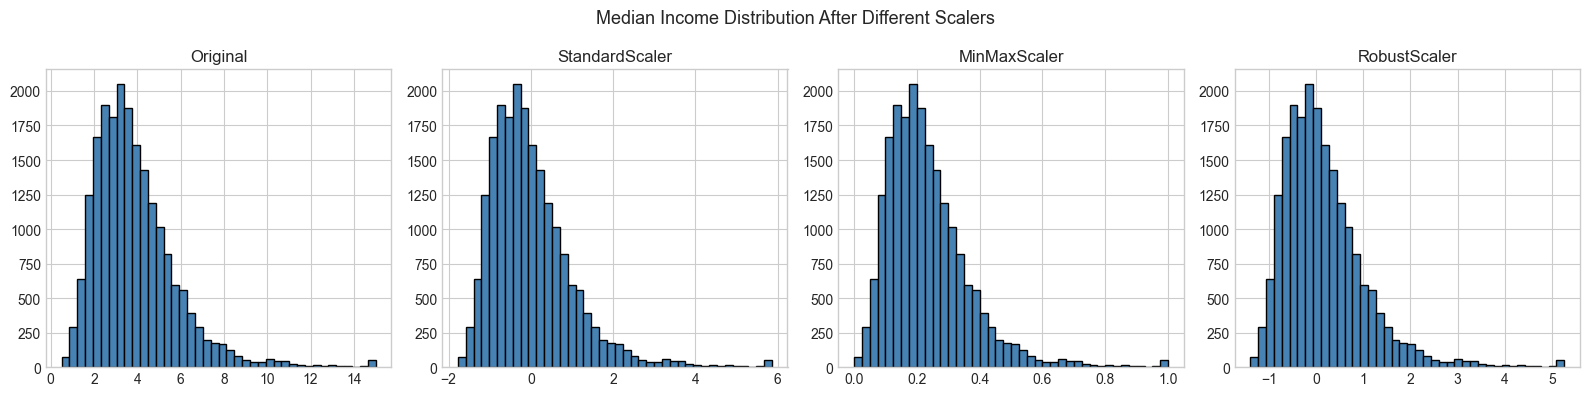

Note: Scaling changes the range, not the shape of the distribution.
Median income is still right-skewed after scaling — for that, use transforms below.


In [23]:
income = df['median_income'].values.reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Original', 'StandardScaler', 'MinMaxScaler', 'RobustScaler']
data   = [
    income,
    StandardScaler().fit_transform(income),
    MinMaxScaler().fit_transform(income),
    RobustScaler().fit_transform(income)
]

for ax, d, title in zip(axes, data, titles):
    ax.hist(d, bins=40, edgecolor='black', color='steelblue')
    ax.set_title(title)

plt.suptitle('Median Income Distribution After Different Scalers', fontsize=13)
plt.tight_layout()
plt.show()

print('Note: Scaling changes the range, not the shape of the distribution.')
print('Median income is still right-skewed after scaling — for that, use transforms below.')

All four histograms have the same shape and the distribution of median income is still right-skewed after scaling. That's by design: scalers only change the range of values, not the shape of the distribution. If you want a more bell-shaped distribution, you need a non-linear transformation.

### Non-Linear Transformations for Skewed Data

Many real-world numeric features are strongly right-skewed — most values are small, but a few are very large. Median income in the California Housing data is a perfect example: most households earn moderate amounts, but a small number earn much more.

Why does skewness cause problems? Linear regression assumes that residuals are roughly normally distributed. Distance-based models like k-NN are distorted when one tail is much longer than the other — a difference of $100K in salary is treated the same as a difference of $100K anywhere along the scale, even though proportionally those are very different gaps. The mean gets pulled far from the typical value.

The good news is that we can reshape a skewed distribution using a transformation. **Log transform** is the classic choice for strongly right-skewed data where all values are positive — it compresses the long tail and spreads out the lower end. We use `log1p` (log of 1 + x) rather than plain log so that zero values don't become negative infinity.

**Square root** is milder and works well for count data or moderate skew. **Box-Cox** and **Yeo-Johnson** are automated transforms that find the optimal power — sklearn's PowerTransformer handles both. The advantage of Box-Cox and Yeo-Johnson over manual log/sqrt is that they choose the best transformation automatically; the disadvantage is that they're harder to interpret and explain.

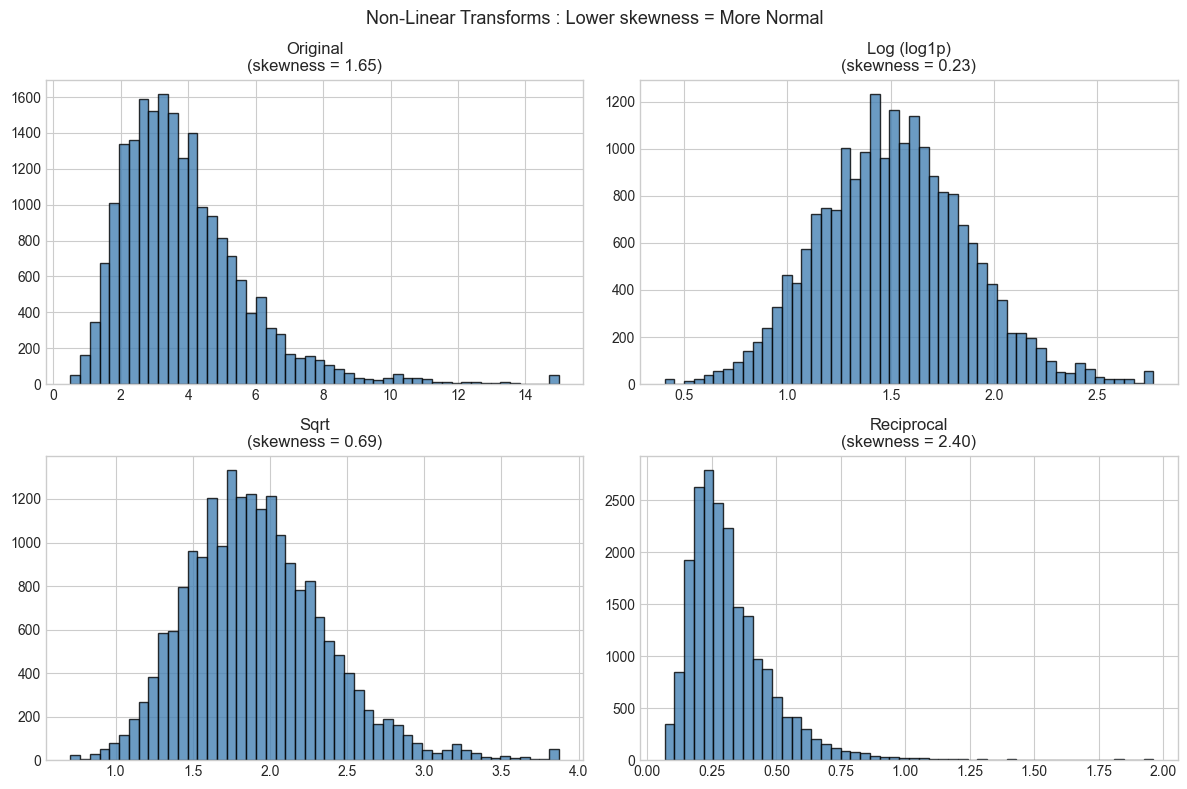

In [30]:
income = df['median_income'].values

transforms = {
    'Original':    income,
    'Log (log1p)': np.log1p(income),
    'Sqrt':        np.sqrt(income),
    'Reciprocal':  1 / (income + 0.01),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, values) in zip(axes, transforms.items()):
    ax.hist(values, bins=50, edgecolor='black', color='steelblue', alpha=0.8)
    skew = pd.Series(values).skew()
    ax.set_title(f'{name}\n(skewness = {skew:.2f})')

plt.suptitle('Non-Linear Transforms : Lower skewness = More Normal', fontsize=13)
plt.tight_layout()
plt.show()

Look at the skewness values in each title. The original median income has a skewness of around 1.5 with a noticeable right tail. After log transform, the skewness drops to near zero and the distribution looks close to bell-shaped. This matters because linear models will fit a log-transformed income feature far more reliably than the raw version.

Box-Cox lambda: 0.091
Box-Cox skewness: 0.005

Yeo-Johnson lambda: -0.199
Yeo-Johnson skewness: -0.003


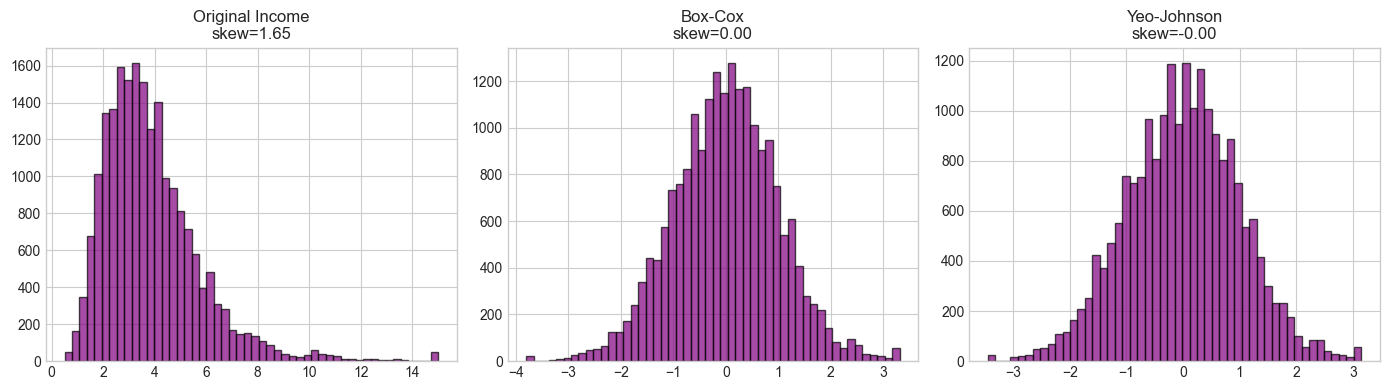

In [33]:
income_2d = df['median_income'].values.reshape(-1, 1)

bc = PowerTransformer(method='box-cox')
income_bc = bc.fit_transform(income_2d).ravel()

print(f'Box-Cox lambda: {bc.lambdas_[0]:.3f}')
print(f'Box-Cox skewness: {pd.Series(income_bc).skew():.3f}')

yj = PowerTransformer(method='yeo-johnson')
income_yj = yj.fit_transform(income_2d).ravel()

print(f'\nYeo-Johnson lambda: {yj.lambdas_[0]:.3f}')
print(f'Yeo-Johnson skewness: {pd.Series(income_yj).skew():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title in zip(
    axes,
    [df['median_income'].values, income_bc, income_yj],
    ['Original Income', 'Box-Cox', 'Yeo-Johnson']
):
    ax.hist(data, bins=50, edgecolor='black', color='purple', alpha=0.7)
    ax.set_title(f'{title}\nskew={pd.Series(data).skew():.2f}')

plt.tight_layout()
plt.show()

### Binning : Turning a Continuous Feature into Categories

Sometimes a continuous feature is more useful as a category. House age is a good example: a model trying to predict house value might benefit more from knowing "is this a new build, a mid-century home, or a pre-war building?" than from the exact number of years.

Binning makes sense when: the relationship between the feature and the target is non-linear (the feature's effect changes across ranges), domain knowledge defines meaningful groups, or you want to handle outliers naturally where the largest value simply goes into the top bin.

There are two main strategies. **Equal-width** bins divide the range into equally spaced intervals. Simple to understand, but if your data is skewed most observations will pile into one or two bins. **Equal-frequency (quantile)** bins put the same number of observations in each bin. Better for skewed data because each bin contributes equally to the model's learning.

In [37]:
house_age = df['house_age'].copy()

df['age_group'] = pd.cut(
    house_age,
    bins=[0, 10, 25, 40, 100],
    labels=['New Build', 'Recent', 'Established', 'Old'])

print('Equal-width domain-driven bins (pd.cut):')
print(df['age_group'].value_counts().sort_index())

df['age_quartile'] = pd.qcut(house_age, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
print('\nEqual-frequency quartile bins (pd.qcut):')
print(df['age_quartile'].value_counts().sort_index())

Equal-width domain-driven bins (pd.cut):
age_group
New Build      1569
Recent         7061
Established    8132
Old            3878
Name: count, dtype: int64

Equal-frequency quartile bins (pd.qcut):
age_quartile
Q1    5326
Q2    5343
Q3    5026
Q4    4945
Name: count, dtype: int64


Uniform (equal-width) bin edges: [ 1.  13.8 26.5 39.2 52. ]
Quantile (equal-frequency) bin edges: [ 1. 18. 29. 37. 52.]


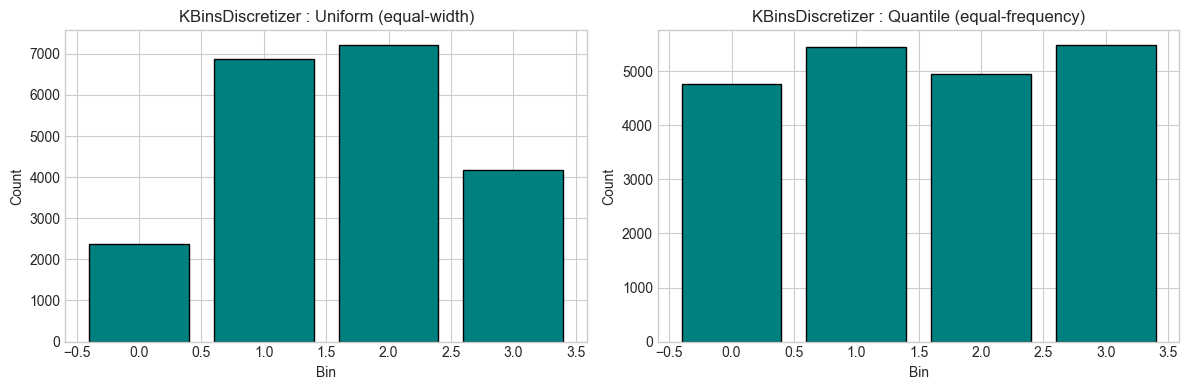

In [41]:
age_2d = house_age.values.reshape(-1, 1)

kbd_uniform  = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')
kbd_quantile = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')

bins_uniform  = kbd_uniform.fit_transform(age_2d).ravel()
bins_quantile = kbd_quantile.fit_transform(age_2d).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, bins, title, bins_obj in zip(
    axes,
    [bins_uniform, bins_quantile],
    ['Uniform (equal-width)', 'Quantile (equal-frequency)'],
    [kbd_uniform, kbd_quantile]
):
    counts = pd.Series(bins).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='teal', edgecolor='black')
    ax.set_title(f'KBinsDiscretizer : {title}')
    ax.set_xlabel('Bin')
    ax.set_ylabel('Count')
    print(f'{title} bin edges: {bins_obj.bin_edges_[0].round(1)}')

plt.tight_layout()
plt.show()

### Polynomial and Interaction Features

Linear models can only learn straight-line relationships: `y = w₁x₁ + w₂x₂ + b`. But what if house value peaks for medium-aged homes and drops for very new or very old ones? That's a curved relationship, and no linear combination of raw features can capture it.

The solution is to add polynomial features like `x²`, `x³`, or products of two features (`x₁ × x₂`) and let the linear model fit the curve through those engineered terms.

`PolynomialFeatures(degree=2)` transforms `[x₁, x₂]` into `[1, x₁, x₂, x₁², x₁·x₂, x₂²]`. That interaction term `x₁·x₂` is particularly valuable when the effect of one feature depends on the value of another.

A word of caution: keep the degree at 2 unless you have strong reason for higher. Degree 3 and above creates explosive numbers of features and makes overfitting very likely. Always validate with cross-validation before committing to polynomial features.

In [44]:
from sklearn.preprocessing import PolynomialFeatures

# Show what PolynomialFeatures creates
X_small = pd.DataFrame({'income': [50000, 80000, 120000], 'age': [25, 40, 55]})

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_small)

poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(['income', 'age']))
print('Original features:')
print(X_small)
print('\nAfter PolynomialFeatures(degree=2):')
print(poly_df)

Original features:
   income  age
0   50000   25
1   80000   40
2  120000   55

After PolynomialFeatures(degree=2):
     income   age      income^2  income age   age^2
0   50000.0  25.0  2.500000e+09   1250000.0   625.0
1   80000.0  40.0  6.400000e+09   3200000.0  1600.0
2  120000.0  55.0  1.440000e+10   6600000.0  3025.0


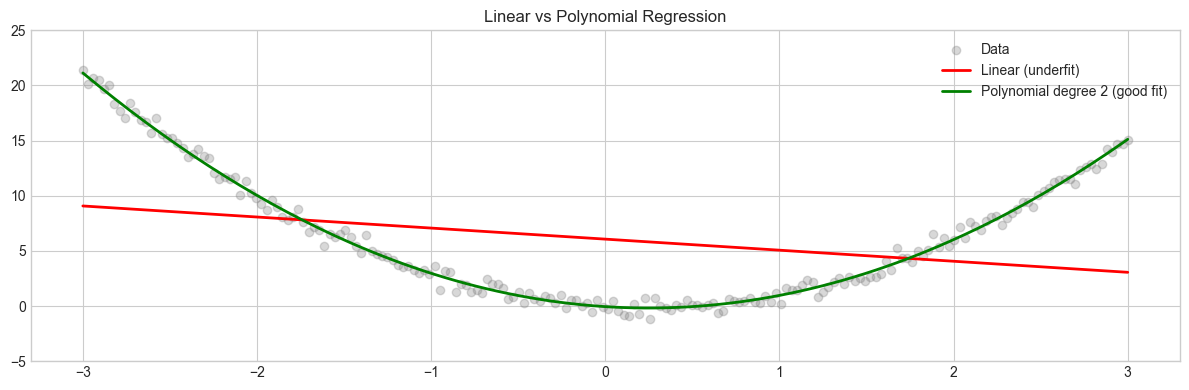

Degree 2 captures the pattern much accurately.


In [52]:
# Demo: curved relationship that linear model can't fit
x = np.linspace(-3, 3, 200).reshape(-1, 1)
y_true = 2 * x.ravel()**2 - x.ravel() + np.random.normal(0, 0.5, 200)

# Linear model
lr = LinearRegression().fit(x, y_true)
y_pred_linear = lr.predict(x)

# Polynomial degree 2 model
poly2 = PolynomialFeatures(degree=2, include_bias=False)
x_poly2 = poly2.fit_transform(x)

lr2 = LinearRegression().fit(x_poly2, y_true)
y_pred_poly2 = lr2.predict(x_poly2)

plt.figure(figsize=(12, 4))
plt.scatter(x, y_true, alpha=0.3, label='Data', color='gray')
plt.plot(x, y_pred_linear, 'r-',  lw=2, label='Linear (underfit)')
plt.plot(x, y_pred_poly2, 'g-',   lw=2, label='Polynomial degree 2 (good fit)')
plt.legend()
plt.title('Linear vs Polynomial Regression')
plt.ylim(-5, 25)
plt.tight_layout()
plt.show()

print('Degree 2 captures the pattern much accurately.')

In [54]:
# Manual interaction features — often more interpretable than sklearn polynomial
df['rooms_per_person']     = df['avg_rooms'] / (df['avg_occupancy'] + 0.01)
df['income_x_house_age']   = df['median_income'] * df['house_age']  # interaction

print('Correlation with house value target:')
corr_cols = ['median_income', 'house_age', 'avg_rooms', 'avg_occupancy',
             'rooms_per_person', 'income_x_house_age']
corr_series = df[corr_cols + ['house_value']].corr()['house_value'].drop('house_value')
print(corr_series.sort_values(ascending=False).round(3))

Correlation with house value target:
median_income         0.688
income_x_house_age    0.589
rooms_per_person      0.210
avg_rooms             0.152
house_age             0.106
avg_occupancy        -0.024
Name: house_value, dtype: float64


### <font color='green'>Key things to remember from this notebook</font>

Scale your features whenever your algorithm is distance-based or uses regularisation and StandardScaler is the default/common choice. When a column is strongly right-skewed, apply `np.log1p()` before scaling; it doesn't change the information in the data, just reshapes it so the model can use it more reliably. Bin features when domain knowledge defines meaningful groups, and be careful with polynomial features — degree 2 is usually enough, and always validate the improvement on held-out data.